# Tutorial 3.1: Getting started with GANs

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Under_Construction&color=orange)


**Open notebook on:** 
[![View filled on Github](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=View%20On%20Github&color=lightgrey)](https://github.com/clandolt/mlcysec_notebooks/blob/main/source/tutorial_notebooks/tutorial3_1_gan_getting_started/tutorial3_1_gan_getting_started.ipynb)
[![Open filled In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/clandolt/mlcysec_notebooks/blob/main/source/tutorial_notebooks/tutorial3_1_gan_getting_started/tutorial3_1_gan_getting_started.ipynb)   
**Author:** Christoph R. Landolt


In tutorial 2.2, we explored the Variational Autoencoder (VAE), a type of generative model. Another, fundamentally different architecture used for data generation is the Generative Adversarial Network (GAN), which consists of two competing neural networks, each with its own objective.

A **Generator** network creates new samples, aiming to produce data indistinguishable from real data. A **Discriminator** network aims to correctly classify samples as either real or synthetically generated by the Generator. This setup creates a competitive, adversarial dynamic.

This adversarial training setup has **dual-use applications** in cybersecurity: it can be used to train highly sophisticated detector networks for Intrusion Detection Systems (IDS), or, conversely, to train 'smart' generators capable of creating evasive attack samples that bypass machine learning-driven IDSs. In this tutorial, we will learn how to implement and train a simple GAN in PyTorch.

## Tutorial Objectives
By the end of this tutorial, you will be able to:
- Explain the core architecture and **adversarial objective** of a Generative Adversarial Network (GAN).
- Implement the Generator and Discriminator neural networks in PyTorch.
- Train a simple GAN to generate synthetic data.

## Game Theory and Generative Adversarial Networks (GANs)

Generative Adversarial Networks (GANs) represent a game between two neural networks trained in an adversarial manner to reach a **zero-sum Nash equilibrium profile**. In this setup, the Generator and Discriminator are engaged in a competitive **minimax game**, striving to outmaneuver each other.

### Basics of GANs in Terms of Game Theory

GANs can be understood as a zero-sum, two-player minimax game, where the two players are the **Generator** $G(z)$ and the **Discriminator** $D(x)$.

<img src="./vanilla_GAN_Architecture.jpg" alt="vanilla_GAN_Architecture" width="600"/>


#### Players

- **Generator $G(z; \theta_G)$:**
    The generator takes a random noise vector $z$, sampled from a prior noise distribution $p_z(z)$ (usually uniform or Gaussian), and maps it to approximate the training data distribution $p_g(x)$. The goal of $G$ is to generate samples indistinguishable from the real data distribution $p_{\text{data}}(x)$.

- **Discriminator $D(x; \theta_D)$:**
    The discriminator takes an input $x$ (either a real sample from $p_{\text{data}}(x)$ or a fake sample from the generator $G$) and outputs a probability $D(x)$ in the range $[0, 1]$, representing its confidence that $x$ is a real sample.

#### Objective

The GAN framework’s objective is to find the Nash equilibrium of the following **minimax game**:

$$
\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{\text{data}}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]
$$

Different choices for the functions $\log D(x)$ and $\log(1 - D(G(z)))$ lead to variations in GAN objectives and metrics (e.g., WGAN, LSGAN).

<table class="tutorial-table" border="1" style="width:100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th>Variant</th>
            <th>f0(D)</th>
            <th>f1(D)</th>
            <th>Divergence Metric</th>
            <th>Game Value</th>
            <th>Description</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><b>Vanilla GAN</b></td>
            <td>log D</td>
            <td>log(1 - D)</td>
            <td>Jensen-Shannon Divergence (JSD)</td>
            <td>-log 4</td>
            <td>The original GAN formulation by Goodfellow et al. (2014).</td>
        </tr>
        <tr>
            <td><b>Wasserstein GAN (WGAN)</b></td>
            <td>D</td>
            <td>-D</td>
            <td>Wasserstein-1 Distance (Earth Mover's)</td>
            <td>0</td>
            <td>WGAN uses the Earth Mover's distance (Wasserstein-1) as a metric, providing better gradients.</td>
        </tr>
        <tr>
            <td><b>Hinge GAN</b></td>
            <td>min(0, -1 + D)</td>
            <td>min(0, -1 - D)</td>
            <td>Hinge Loss</td>
            <td>0</td>
            <td>Hinge loss encourages the discriminator to correctly classify real and fake samples with a margin.</td>
        </tr>
        <tr>
            <td><b>f-GAN (KL)</b></td>
            <td>log D</td>
            <td>1 - D</td>
            <td>Kullback-Leibler (KL) Divergence</td>
            <td>0</td>
            <td>f-GAN with KL divergence as the f-divergence.</td>
        </tr>
        <tr>
            <td><b>f-GAN (Reverse KL)</b></td>
            <td>-D</td>
            <td>log D</td>
            <td>Reverse Kullback-Leibler (Reverse KL)</td>
            <td>-1</td>
            <td>f-GAN with Reverse KL divergence as the f-divergence.</td>
        </tr>
    </tbody>
</table>

The original formulation by [Goodfellow et al.](https://arxiv.org/abs/1406.2661) uses **cross-entropy loss** for adversarial dynamics.

*   [**Wasserstein GAN (WGAN):**](https://arxiv.org/abs/1701.07875) Uses the **Earth Mover’s distance** for stable gradient flow and improved convergence.
*   [**Hinge GAN:**](https://arxiv.org/abs/1705.02894) Uses the **Hinge Loss** and encourages a margin between correct and incorrect classifications.

### Detailed Objectives

#### Discriminator’s Objective

The discriminator $D$ seeks to **maximize** its ability to distinguish real samples ($x$) from fake samples ($G(z)$):

$$
\max_D V(D, G) = \mathbb{E}_{x \sim p_{\text{data}}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]
$$

#### Generator’s Objective

The generator $G$ seeks to **minimize** the discriminator’s ability to correctly classify fake samples as generated:

$$
\min_G V(D, G) = \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]
$$

### Minimax Game Interpretation

The GAN framework models a **zero-sum game** where the generator $G$ and the discriminator $D$ compete.

*   The generator $G$ aims to create samples that are indistinguishable from real data.
*   The discriminator $D$ aims to accurately classify samples as real or generated.

The **Nash equilibrium** is reached when $p_g = p_{\text{data}}$ and the discriminator is unable to distinguish the two distributions, resulting in:

$$
D^*(x)=0.5 \quad \text{for all } x
$$

#### Optimality

The optimal discriminator $D^*$ and generator $G^*$ satisfy:

$$
D^*(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)}
$$

and

$$
p_g = p_{\text{data}}
$$

At this point, the generator perfectly replicates the real data distribution, and the discriminator cannot distinguish between real and generated samples. This game-theoretic foundation not only explains the dynamics of GANs but also highlights their flexibility for various tasks, from image synthesis to adversarial data generation.

## 2. Implementation of a Simple Vanilla GAN in PyTorch
We will implement a simple **Vanilla GAN** to generate 2D data points that follow a multimodal Gaussian distribution (two distinct clusters).

#### Step 1: Define Network Architectures and Data Functions

We define the Generator and Discriminator as simple Multi-Layer Perceptrons (MLPs). The `generate_real_data` function simulates a real-world dataset with two distinct clusters.

In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Define the Generator model
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # Input dimension is 10 (noise), output dimension is 2 (for 2D data)
        self.fc = nn.Sequential(
            nn.Linear(10, 50),
            nn.ReLU(),
            nn.Linear(50, 2)
        )

    def forward(self, x):
        return self.fc(x)

# Define the Discriminator model
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        # Input dimension is 2 (for 2D data), output dimension is 1 (binary classification)
        self.fc = nn.Sequential(
            nn.Linear(2, 50),
            nn.ReLU(),
            nn.Linear(50, 1),
            nn.Sigmoid()        # Sigmoid activation to output probabilities
        )

    def forward(self, x):
        return self.fc(x)

# Toy dataset with multimodal Gaussian distribution (two clusters)
def generate_real_data(batch_size=64, mean1=0.0, mean2=10.0, std=1.0):
    # Half of the samples from mean1
    half_batch = batch_size // 2
    data1 = np.random.normal(mean1, std, (half_batch, 2))

    # Half of the samples from mean2
    data2 = np.random.normal(mean2, std, (batch_size - half_batch, 2))

    # Combine both parts
    combined_data = np.vstack([data1, data2])

    # Convert to torch tensor
    return torch.tensor(combined_data, dtype=torch.float32)

# Function to generate noise vector for the Generator
def generate_noise(batch_size=64, noise_dim=10):
    return torch.tensor(np.random.randn(batch_size, noise_dim), dtype=torch.float32)

#### Step 2: Initialization and Training Setup
We initialize the models, the Binary Cross-Entropy (BCE) loss function, and the Adam optimizers for both the Generator ($G$) and the Discriminator ($D$).

In [2]:
# Initialization
generator = Generator()
discriminator = Discriminator()
criterion = nn.BCELoss() # Standard loss for Vanilla GAN
optimizer_g = optim.Adam(generator.parameters(), lr=0.001)
optimizer_d = optim.Adam(discriminator.parameters(), lr=0.001)

# Training parameters
num_epochs = 10000
batch_size = 64
noise_dim = 10

losses_d = []
losses_g = []

#### Step 3: The Adversarial Training Loop
he core of the GAN training involves alternating updates: first, updating the Discriminator ($D$) to correctly classify real and fake samples, and second, updating the Generator ($G$) to fool the Discriminator.

In [3]:
# Training loop
for epoch in range(num_epochs):
    # --- 1. Train Discriminator ---
    optimizer_d.zero_grad()

    # Generate real and fake data
    real_data = generate_real_data(batch_size)
    # Detach fake data to prevent gradients from flowing back to the Generator
    fake_data = generator(generate_noise(batch_size, noise_dim)).detach()

    # D Loss on REAL data (target: 1)
    real_labels = torch.ones(batch_size, 1)
    output_real = discriminator(real_data)
    loss_d_real = criterion(output_real, real_labels)

    # D Loss on FAKE data (target: 0)
    fake_labels = torch.zeros(batch_size, 1)
    output_fake = discriminator(fake_data)
    loss_d_fake = criterion(output_fake, fake_labels)

    # Total loss and update Discriminator
    loss_d = loss_d_real + loss_d_fake
    loss_d.backward()
    optimizer_d.step()

    # --- 2. Train Generator ---
    optimizer_g.zero_grad()

    # Generate new fake data (not detached)
    fake_data = generator(generate_noise(batch_size, noise_dim))

    # G Loss (target: 1 -> Generator tries to fool D into thinking fake data is real)
    real_labels = torch.ones(batch_size, 1)
    output_fake = discriminator(fake_data)
    loss_g = criterion(output_fake, real_labels)

    # Update Generator
    loss_g.backward()
    optimizer_g.step()

    # Save losses and print progress
    losses_d.append(loss_d.item())
    losses_g.append(loss_g.item())

    if epoch % 1000 == 0:
        print(f'Epoch [{epoch}/{num_epochs}], Loss D: {loss_d.item():.4f}, Loss G: {loss_g.item():.4f}')

Epoch [0/10000], Loss D: 1.9201, Loss G: 0.6299
Epoch [1000/10000], Loss D: 1.0818, Loss G: 0.9747
Epoch [2000/10000], Loss D: 1.1941, Loss G: 0.8554
Epoch [3000/10000], Loss D: 1.0745, Loss G: 1.0045
Epoch [4000/10000], Loss D: 1.1104, Loss G: 0.9490
Epoch [5000/10000], Loss D: 1.0999, Loss G: 0.9845
Epoch [6000/10000], Loss D: 1.0807, Loss G: 1.0573
Epoch [7000/10000], Loss D: 0.9956, Loss G: 1.0994
Epoch [8000/10000], Loss D: 1.0082, Loss G: 1.0921
Epoch [9000/10000], Loss D: 0.9462, Loss G: 1.1583


#### Step 4: Visualization and Evaluation
We visualize the training progress by plotting the Generator and Discriminator losses and then compare the generated data against the real data distribution.

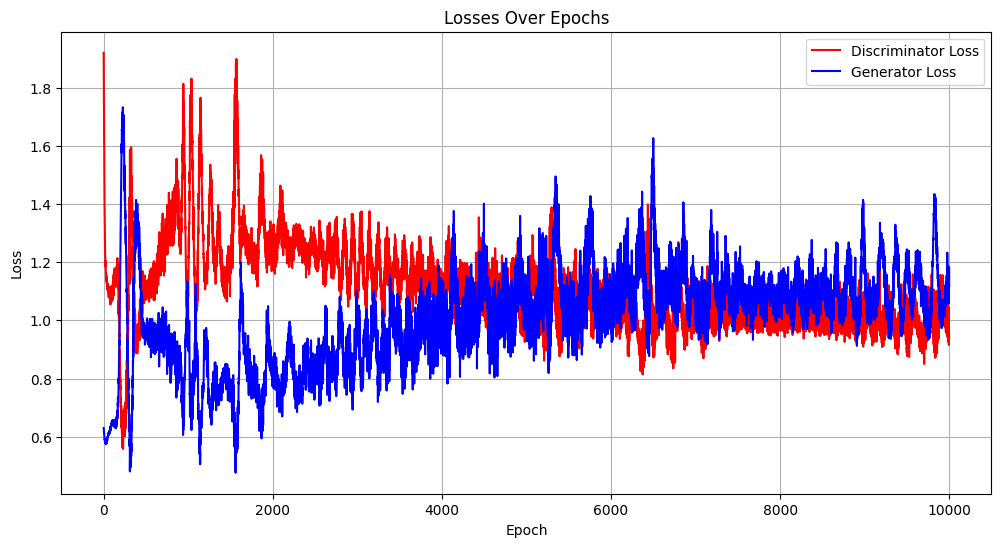

In [4]:
# Plot the losses
plt.figure(figsize=(12, 6))
plt.plot(losses_d, label='Discriminator Loss', color='red')
plt.plot(losses_g, label='Generator Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Losses Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

**Notes:** 

- **Interpreting Oscillating Losses:** The Generator and Discriminator losses in the plot are **oscillating** rather than smoothly decreasing. This instability is typical for GANs because training seeks a **Nash equilibrium** where neither network can unilaterally improve. This characteristic makes the training of GANs **unstable** and **challenging**.

- **Vanishing Gradients and Training Instability:** The original GAN objective for the generator is to minimize `log(1 - D(G(z)))`. This objective function can lead to the problem of **vanishing gradients**, especially early in the training process.

*   **When the Discriminator is Strong:** If the discriminator becomes very effective at distinguishing real from fake data, its output for fake samples, `D(G(z))`, will be close to 0.
*   **Saturated Loss Function:** The gradient of the `log(1 - x)` function is flattest when `x` is close to 0. Consequently, when the generator is performing poorly and the discriminator is strong, the generator receives a very small gradient signal. This means it learns extremely slowly or gets stuck, unable to improve.

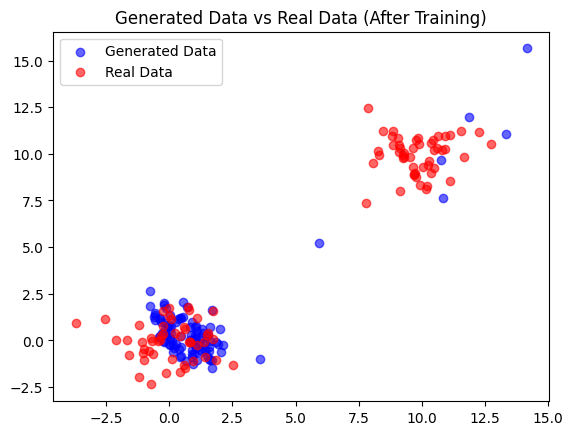

In [5]:
# Plot results
with torch.no_grad():
    noise = generate_noise(100, noise_dim)
    generated_data = generator(noise).numpy()

# Note: generate_real_data() is called again to get fresh real data for the plot
plt.scatter(generated_data[:, 0], generated_data[:, 1], c='blue', label='Generated Data', alpha=0.6)
plt.scatter(generate_real_data(100).numpy()[:, 0], generate_real_data(100).numpy()[:, 1], c='red', label='Real Data', alpha=0.6)
plt.legend()
plt.title('Generated Data vs Real Data (After Training)')
plt.show()

**Notes:**

- **Mode Collapse:** The scatter plot of our Vanilla GAN clearly shows **mode collapse**. The real data has two distinct clusters (modes), but the generator has learned to produce samples for only one of them.
-   **How it Happens:** Mode collapse occurs when the generator discovers a small region of the data manifold that can consistently fool the discriminator. For example, it might find that producing points for the bottom-left cluster is an "easy win."
-   **The Vicious Cycle:** Once the generator starts exclusively producing samples from this single mode, the discriminator's training becomes focused on learning to distinguish this specific type of fake data from the real data. The discriminator becomes a highly specialized expert at identifying that one mode but remains weak and provides uninformative gradients for any other potential outputs. Because the generator's only feedback comes from this narrowly focused discriminator, it receives no incentive to explore other modes and diversify its output. It gets stuck in a local equilibrium, winning the game by repeatedly playing the same move, thereby failing to capture the true diversity of the data distribution.

These challenges are the primary motivation for developing more advanced GAN architectures like the MAD-GAN, which explicitly introduces mechanisms to encourage diversity and stabilize training.

## Advanced GAN Training: Multi-Agent Diverse GAN (MAD-GAN) Setup

While the Vanilla GAN provides a strong foundation, its training is often unstable and prone to **mode collapse** (where the generator only learns to produce a small subset of the data distribution). Game theory offers solutions to these issues by adapting the adversarial dynamics. In this section, we implement a **Multi-Agent GAN (MAD-GAN)** setup using two competing generators to visualize how multi-generator dynamics can increase training stability and improve output diversity.

#### Conceptual Advancements

Game theory provides a natural framework for analyzing and improving the training and performance of GANs, tackling challenges such as instability, non-convergence, and **mode collapse**.

- **Multi-Agent Games:** MAD-GANs leverage game-theoretic principles to employ multiple generators and a single discriminator. By having multiple generators compete to cover the data distribution, the architecture explicitly addresses **mode collapse**, ensuring diverse output generation.
- **Stochastic Games:** Casts GAN training as a **Stochastic Nash Equilibrium Problem (SNEP)** to improve convergence and stability in non-convex loss landscapes.
- **Architectural Modifications:** These multi-agent architectures often integrate concepts like Nash equilibria for enhanced training dynamics.

The training loss in this multi-agent setup will show complex interactions as the generators compete for coverage while the discriminator tries to learn the boundaries of both.
<img src="./multi_stackelber_GAN_Architecture.jpg" alt="multi_stackelber_GAN_Architecture" width="600"/>


#### Step 1: Define Multi-Agent Network Architectures
We reuse the basic MLP structure but define two separate Generator instances ($G_1$ and G_2) to handle the multi-agent competition.


In [6]:
# Import necessary libraries (Assuming already done)
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import numpy as np
# import matplotlib.pyplot as plt

# Define the Generator model (reused from Step 1)
class Generator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Generator, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, output_dim)
        )

    def forward(self, x):
        return self.fc(x)

# Define the Discriminator model (reused from Step 1)
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.fc(x)

#### Step 2: Initialization for Multi-Agent Training
We initialize two distinct Generators (G_1 and G_2) and their respective optimizers. The utility functions generate_real_data and generate_noise from Step 1 are reused.

In [7]:
# Initialization
input_dim = 10  # Dimension of noise vector
output_dim = 2  # Dimension of generated data (2D)

generator_1 = Generator(input_dim, output_dim)
generator_2 = Generator(input_dim, output_dim)
discriminator = Discriminator(output_dim)
criterion = nn.BCELoss()

# Optimizers for all three agents
optimizer_g1 = optim.Adam(generator_1.parameters(), lr=0.001)
optimizer_g2 = optim.Adam(generator_2.parameters(), lr=0.001)
optimizer_d = optim.Adam(discriminator.parameters(), lr=0.001)

# Training parameters
num_epochs = 10000
batch_size = 64

losses_d = []
losses_g1 = []
losses_g2 = []

#### Step 3: The Multi-Agent Adversarial Training Loop
The training involves sequential updates for the three agents: the Discriminator updates its weights based on both fake distributions, followed by separate updates for Generator 1 and Generator 2.

In [8]:
# Training loop
for epoch in range(num_epochs):
    # --- 1. Train Discriminator (D) ---
    optimizer_d.zero_grad()

    # Generate data from both generators
    noise = generate_noise(batch_size)
    fake_data_1 = generator_1(noise)
    # Detach G2 data: ensures D update uses fixed G2 parameters for this step
    fake_data_2 = generator_2(noise).detach()

    # D Loss on REAL data (target: 1)
    real_data = generate_real_data(batch_size)
    real_labels = torch.ones(batch_size, 1)
    loss_d_real = criterion(discriminator(real_data), real_labels)

    # D Loss on FAKE data (target: 0) - Must correctly classify both fake batches
    fake_labels = torch.zeros(batch_size, 1)
    loss_d_fake = criterion(discriminator(fake_data_1), fake_labels) + \
                  criterion(discriminator(fake_data_2), fake_labels)

    # Total loss and update Discriminator
    loss_d = loss_d_real + loss_d_fake
    loss_d.backward()
    optimizer_d.step()

    # --- 2. Train Generator 1 (G1) ---
    optimizer_g1.zero_grad()
    fake_data_1 = generator_1(generate_noise(batch_size))
    # G1 Goal: Fool D (target: 1)
    loss_g1 = criterion(discriminator(fake_data_1), torch.ones(batch_size, 1))
    loss_g1.backward()
    optimizer_g1.step()

    # --- 3. Train Generator 2 (G2) ---
    optimizer_g2.zero_grad()
    fake_data_2 = generator_2(generate_noise(batch_size))
    # G2 Goal: Fool D (target: 1)
    loss_g2 = criterion(discriminator(fake_data_2), torch.ones(batch_size, 1))
    loss_g2.backward()
    optimizer_g2.step()

    losses_d.append(loss_d.item())
    losses_g1.append(loss_g1.item())
    losses_g2.append(loss_g2.item())

    # Print progress
    if epoch % 1000 == 0:
        print(f'Epoch [{epoch}/{num_epochs}], Loss D: {loss_d.item():.4f}, Loss G1: {loss_g1.item():.4f}, Loss G2: {loss_g2.item():.4f}')

Epoch [0/10000], Loss D: 2.5599, Loss G1: 0.6982, Loss G2: 0.6362
Epoch [1000/10000], Loss D: 1.8629, Loss G1: 1.1820, Loss G2: 0.9902
Epoch [2000/10000], Loss D: 1.8978, Loss G1: 1.1358, Loss G2: 1.1259
Epoch [3000/10000], Loss D: 1.9692, Loss G1: 1.0566, Loss G2: 1.0937
Epoch [4000/10000], Loss D: 1.9038, Loss G1: 1.2443, Loss G2: 1.0469
Epoch [5000/10000], Loss D: 1.7370, Loss G1: 1.1353, Loss G2: 1.0847
Epoch [6000/10000], Loss D: 1.8147, Loss G1: 1.1980, Loss G2: 0.9955
Epoch [7000/10000], Loss D: 1.8262, Loss G1: 0.9832, Loss G2: 1.3342
Epoch [8000/10000], Loss D: 1.8285, Loss G1: 1.0672, Loss G2: 1.2244
Epoch [9000/10000], Loss D: 1.8082, Loss G1: 1.1706, Loss G2: 1.0990


#### 4: Visualization and Evaluation
We visualize the losses, noting the three competing loss curves, and plot the generated data to see if the multi-agent setup resulted in better coverage of the two real data clusters.

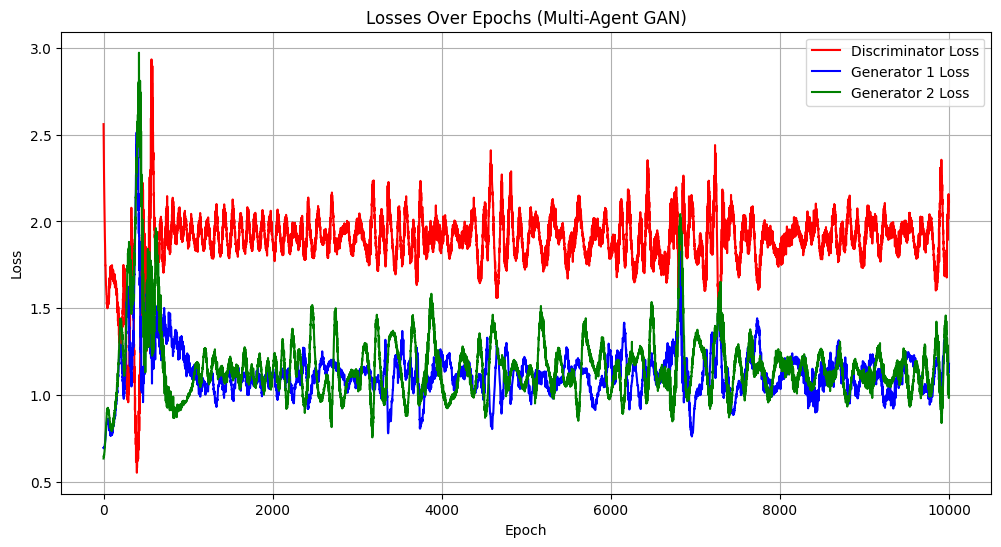

In [9]:
# Plot the losses
plt.figure(figsize=(12, 6))
plt.plot(losses_d, label='Discriminator Loss', color='red')
plt.plot(losses_g1, label='Generator 1 Loss', color='blue')
plt.plot(losses_g2, label='Generator 2 Loss', color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Losses Over Epochs (Multi-Agent GAN)')
plt.legend()
plt.grid(True)
plt.show()

**Note: Multi-Agent Loss Dynamics**

The loss curves for the two Generators ($G_1$ and $G_2$) show their independent, yet coupled, struggle against the Discriminator.

- **Symmetric Loss Components:** Due to the symmetric nature of the GAN's objective, the difficulty for the Discriminator to correctly classify *all* fake data is the sum of the difficulties posed by $G_1$'s output and $G_2$'s output.
- **Competition and Specialization:** The generators compete against each other to cover the real data distribution. Ideally, in a **Multi-Agent GAN**, this competition leads to specialization, where $G_1$ might focus on one cluster (mode) of the real data, and $G_2$ on the other, thereby reducing overall **mode collapse**.

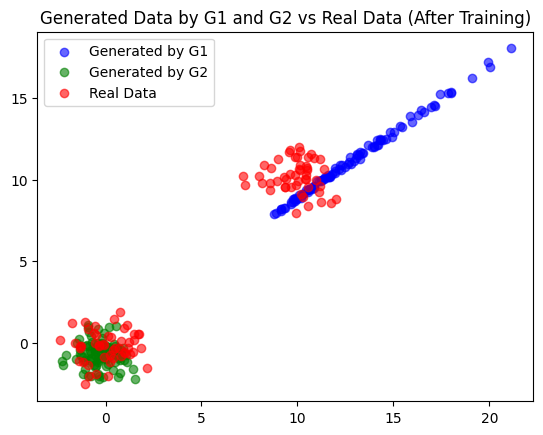

In [10]:
# Plot results
with torch.no_grad():
    noise = generate_noise(100)
    generated_data_1 = generator_1(noise).numpy()
    generated_data_2 = generator_2(noise).numpy()

plt.scatter(generated_data_1[:, 0], generated_data_1[:, 1], c='blue', label='Generated by G1', alpha=0.6)
plt.scatter(generated_data_2[:, 0], generated_data_2[:, 1], c='green', label='Generated by G2', alpha=0.6)
plt.scatter(generate_real_data(100).numpy()[:, 0], generate_real_data(100).numpy()[:, 1], c='red', label='Real Data', alpha=0.6)
plt.legend()
plt.title('Generated Data by G1 and G2 vs Real Data (After Training)')
plt.show()

## Exercises

These exercises are designed to test your understanding of the concepts covered in this tutorial. The exercises can be solved by modifiing the existing code, implement different GAN variants, and analyze the training dynamics.

### Exercise 1: Experimenting with Architectural Changes

The performance of a GAN is highly sensitive to its architecture and hyperparameters. In this exercise, you will investigate how changing the capacity of the Generator and Discriminator affects the training outcome of the **Vanilla GAN**.

**Instructions:**

1.  **Increase Generator Capacity:** Modify the `Generator` class by adding an additional hidden layer. For example, change the architecture from `Linear(10, 50) -> ReLU -> Linear(50, 2)` to `Linear(10, 128) -> ReLU -> Linear(128, 128) -> ReLU -> Linear(128, 2)`. Re-train the GAN.

2.  **Increase Discriminator Capacity:** Now apply a similar capacity increase to the `Discriminator` class. Re-train the GAN.

3.  **Imbalance the Networks:** Use the high-capacity Generator from step 1 and the original, low-capacity Discriminator. Then, do the opposite: use the original Generator with the high-capacity Discriminator.

**Follow-up Questions:**

In [11]:
# 1) For each experiment, observe the final generated data plot and the loss curves.
# 2) Which combination produced the best results in terms of covering both data modes?
# 3) What happens when one network is significantly more powerful than the other? How does this relate to the "delicate balancing act" mentioned in the tutorial?

### Exercise 2: Implementing the Wasserstein GAN (WGAN)

The tutorial introduced several GAN variants, including the Wasserstein GAN (WGAN), which is known for its improved training stability. Your task is to modify the **Vanilla GAN** code provided in Section 2 to implement a WGAN.

**Instructions:**

Based on the description in the tutorial's table and the principles of WGAN, make the following changes to the Vanilla GAN implementation:

1.  **Modify the Discriminator (Critic):** In a WGAN, the discriminator is often called a "critic" because it outputs an unbounded score (a real number) rather than a probability. Remove the final `nn.Sigmoid()` activation function from the discriminator's architecture.

2.  **Change the Loss Function:** Replace the `nn.BCELoss()` with a loss function that reflects the Wasserstein-1 distance.
    *   **Critic Loss:** The critic tries to maximize the difference between the scores of real and fake data. The loss should be `torch.mean(critic(fake_data)) - torch.mean(critic(real_data))`.
    *   **Generator Loss:** The generator tries to maximize the critic's score for its fake data. The loss should be `-torch.mean(critic(fake_data))`.

3.  **Implement Weight Clipping:** To enforce the Lipschitz constraint required by the WGAN formulation, you must clip the weights of the critic after every update. After `optimizer_d.step()`, iterate through the critic's parameters and clamp their values to a small range, such as `[-0.01, 0.01]`.
    *   **Hint:** You can do this with a loop: `for p in discriminator.parameters(): p.data.clamp_(-0.01, 0.01)`.

4.  **Adjust the Optimizer:** The original WGAN paper suggests using the RMSprop optimizer instead of Adam for better stability. Try switching the discriminator's optimizer to `torch.optim.RMSprop`.

In [12]:
# Implement the Wasserstein GAN (WGAN)

# 1. Modify the Discriminator to output unbounded real values (remove Sigmoid) and replace it with a linear output layer.

# 2. Change the Loss Functions to use the Wasserstein loss
# 2.1 The Wasserstein loss for the Discriminator is defined as: D_loss = -torch.mean(D(real)) + torch.mean(D(fake))
# 2.2 The Wasserstein loss for the Generator is defined as: G_loss = -torch.mean(D(fake))

# 3. Implement Weight Clipping: After each update of the Discriminator, clip its weights to a small range (e.g., [-0.01, 0.01]) to enforce the Lipschitz constraint.

# 4. Adjust the Optimizer: The original WGAN paper suggests using the RMSprop optimizer instead of Adam for better stability. Try switching the discriminator's optimizer to `torch.optim.RMSprop`.

## Further Reading: Evaluating GAN Performance

While visual inspection is a valuable first step, especially for simple 2D data, it becomes subjective and unreliable for complex, high-dimensional data like images. To rigorously assess GAN performance, several quantitative metrics have been developed. These are crucial for comparing different models and tracking training progress. Here are a few key metrics to explore:

-   [**Inception Score (IS):**](https://en.wikipedia.org/wiki/Inception_score) One of the earlier metrics, IS evaluates both the *quality* (clarity and object-likeness) and *diversity* of generated images. It uses a pre-trained Inception-v3 network to measure two properties: the confidence of the classifier's predictions on generated images (high confidence suggests high quality) and the uniformity of the distribution of those predictions (a uniform distribution suggests high diversity). A higher IS is better. However, it does not directly compare the generated distribution to the real data distribution.

-   [**Fréchet Inception Distance (FID):**](https://en.wikipedia.org/wiki/Fr%C3%A9chet_inception_distance) FID is the current industry standard and improves upon IS by directly comparing the statistics of the generated data distribution with the real data distribution. It uses activations from an intermediate layer of the Inception-v3 network to summarize the real and fake datasets. The Fréchet distance between these two summary statistics is then calculated. A **lower FID score is better**, indicating that the two distributions are more similar.

-   [**Precision and Recall:**](https://arxiv.org/abs/1904.06991) Inspired by classification metrics, this framework offers a more disentangled view of a GAN's performance, helping diagnose specific failure modes:
    -   **Precision** measures the fraction of generated samples that are considered realistic or fall within the true data manifold. It is an indicator of sample *quality*.
    -   **Recall** measures the fraction of the real data distribution that the generator is able to cover. It is an indicator of sample *diversity* and is particularly useful for detecting mode collapse (which results in low recall).

A good GAN should ideally achieve both high precision and high recall, but these metrics allow for a more nuanced analysis of the trade-offs between generation quality and diversity.
## Conclusion

This tutorial provided a hands-on introduction to Generative Adversarial Networks, framing them within the principles of game theory. We began by implementing a Vanilla GAN, which successfully learned to generate data but also demonstrated the classic training challenges inherent to this architecture: unstable, oscillating losses and mode collapse, where the generator failed to capture the full diversity of the data distribution.

By analyzing these failure modes, we highlighted how the delicate equilibrium of the adversarial game can break down. We then explored a game-theory-inspired solution, the Multi-Agent Diverse GAN (MAD-GAN), which employs multiple generators competing against a single discriminator. Our implementation showed that this multi-agent setup can effectively mitigate mode collapse. The competing generators were incentivized to specialize and cover different modes of the data distribution, resulting in a more diverse and representative set of generated samples.

Ultimately, this tutorial illustrates that while simple GANs are powerful, understanding their limitations through the lens of game theory opens the door to designing more robust, stable, and capable generative models for a wide range of applications.


---

[![Star our repository](https://img.shields.io/static/v1.svg?logo=star&label=⭐&message=Star%20Our%20Repository&color=yellow)](https://github.com/clandolt/mlcysec_notebooks/)  If you found this tutorial helpful, please **⭐ star our repository** to show your support.   
[![Ask questions](https://img.shields.io/static/v1.svg?logo=star&label=❔&message=Ask%20Questions&color=9cf)](https://github.com/clandolt/mlcysec_notebooks/issues)  For any **questions**, **typos**, or **bugs**, kindly open an issue on GitHub — we appreciate your feedback!

---